# Notebook 2: Aggregated Attribution Analysis

This notebook analyzes the relationship between attribution patterns and model outcomes at the dataset level:

1. **Section 2a**: Does attribution on certain input factors correlate with prediction performance?
2. **Section 2b**: Does attribution on certain input factors correlate with model certainty?

In [1]:
import sys
import os
from pathlib import Path
import pickle
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Add src directory to path (robust path handling)
NOTEBOOK_DIR = Path().resolve()
SRC_DIR = NOTEBOOK_DIR.parent.parent  # interpretability/notebooks -> interpretability -> src
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
print(f"Source directory: {SRC_DIR}")

from aa_philipp.classes.suffix_samples import SuffixSamples
from aa_philipp.classes.sequence import Sequence
from aa_philipp.model_with_integrated_gradients.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from aa_philipp.model_with_integrated_gradients.embedder import get_final_process_step
from aa_philipp.model_with_integrated_gradients.targeter import ActivityTargeter, TimeTargeter
from aa_philipp.model_with_integrated_gradients.dropout_uncertainty_decoder_forward_simplified import PSP_Model_simplified
from evaluation.evaluation import Evaluation

from captum.attr import IntegratedGradients

# Set seeds for reproducibility
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

Source directory: /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src


## Load Model and Data

In [2]:
# Load model (paths relative to SRC_DIR)
file_path_model = SRC_DIR / 'notebooks/training_variational_dropout/Helpdesk/Helpdesk_full_grad_norm_philipp_4layer.pkl'
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(file_path_model), dropout=0.0)
model.eval()

# Load test dataset
file_path_data_set = SRC_DIR.parent / 'encoded_data/test_philipp/helpdesk_all_5_test.pkl'
helpdesk_test_dataset = torch.load(str(file_path_data_set), weights_only=False)

print(f"Model loaded: {file_path_model}")
print(f"Dataset loaded: {len(helpdesk_test_dataset)} samples")

Data set categories:  ([('Activity', 16, {'Assign seriousness': 1, 'Closed': 2, 'Create SW anomaly': 3, 'DUPLICATE': 4, 'EOS': 5, 'INVALID': 6, 'Insert ticket': 7, 'RESOLVED': 8, 'Require upgrade': 9, 'Resolve SW anomaly': 10, 'Resolve ticket': 11, 'Schedule intervention': 12, 'Take in charge ticket': 13, 'VERIFIED': 14, 'Wait': 15}), ('Resource', 24, {'EOS': 1, 'Value 1': 2, 'Value 10': 3, 'Value 11': 4, 'Value 12': 5, 'Value 13': 6, 'Value 14': 7, 'Value 15': 8, 'Value 16': 9, 'Value 17': 10, 'Value 18': 11, 'Value 19': 12, 'Value 2': 13, 'Value 20': 14, 'Value 21': 15, 'Value 22': 16, 'Value 3': 17, 'Value 4': 18, 'Value 5': 19, 'Value 6': 20, 'Value 7': 21, 'Value 8': 22, 'Value 9': 23}), ('Variant index', 175, {'1.0': 1, '10.0': 2, '100.0': 3, '103.0': 4, '104.0': 5, '107.0': 6, '109.0': 7, '11.0': 8, '110.0': 9, '112.0': 10, '113.0': 11, '114.0': 12, '115.0': 13, '117.0': 14, '118.0': 15, '12.0': 16, '120.0': 17, '122.0': 18, '123.0': 19, '124.0': 20, '125.0': 21, '126.0': 22, '1

In [3]:
# Load pre-computed inference results
results_path = SRC_DIR / 'aa_philipp/notebooks/results_store_helpdesk_results.pkl'

with open(results_path, 'rb') as f:
    results_df = pickle.load(f)

results_df = pd.DataFrame(results_df)

# Ensure metrics are computed
if 'brier_score_activities' not in results_df.columns:
    results_df['brier_score_activities'] = results_df.apply(
        SuffixSamples.calculate_brier_score_full_suffix, axis=1
    )

if 'shannon_entropy_activities' not in results_df.columns:
    results_df['shannon_entropy_activities'] = results_df.apply(
        SuffixSamples.calculate_shannon_entropy_on_activity_suffix, axis=1
    )

if 'actual_suffix_length' not in results_df.columns:
    def get_suffix_length(row):
        ss = SuffixSamples.from_row(row)
        return len(ss.suffix.event_list)
    results_df['actual_suffix_length'] = results_df.apply(get_suffix_length, axis=1)

print(f"Loaded {len(results_df)} inference results")
results_df.head()

Loaded 3329 inference results


,case_name,prefix_len,prefix,suffix,mean_prediction,predicted_suffixes,database_index,brier_score_activities,shannon_entropy_activities,actual_suffix_length
0,Case 4220,1,"[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Take in charge ticket', 'Resour...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[[{'Activity': 'Resolve ticket', 'Resource': '...",0,1.0,-0.0,3
1,Case 4220,2,"[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[[{'Activity': 'Resolve ticket', 'Resource': '...",0,0.0,-0.0,2
2,Case 4220,3,"[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Closed', 'Resource': 'Value 5',...","[{'Activity': 'Closed', 'Resource': 'Value 5',...","[[{'Activity': 'Closed', 'Resource': 'Value 5'...",0,0.0,-0.0,1
3,Case 4461,1,"[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Take in charge ticket', 'Resour...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[[{'Activity': 'Take in charge ticket', 'Resou...",1,1.0,-0.0,3
4,Case 4461,2,"[{'Activity': 'Assign seriousness', 'Resource'...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[{'Activity': 'Resolve ticket', 'Resource': 'V...","[[{'Activity': 'Resolve ticket', 'Resource': '...",1,0.0,-0.0,2


In [4]:
# Setup evaluation object
evaluation = Evaluation(
    model=model,
    dataset=helpdesk_test_dataset,
    concept_name='Activity',
    growing_num_values=['case_elapsed_time'],
    all_cat=['Activity', 'Resource'],
    all_num=['case_elapsed_time', 'event_elapsed_time']
)

prefix_cat_attributes = evaluation.prefix_cat_attributes
print(f"Categorical attributes: {prefix_cat_attributes}")

Categorical attributes: ['Activity', 'Resource', 'Variant index', 'seriousness', 'customer', 'product', 'responsible_section', 'seriousness_2', 'service_level', 'service_type', 'support_section', 'workgroup']


## Helper Functions

In [5]:
def forward_for_ig(model, prefix, target_fn):
    """Forward function for Integrated Gradients."""
    simplified_model = PSP_Model_simplified(model=model)
    predictions = simplified_model.forward(prefix=prefix)
    target = target_fn(predictions)
    return target


def compute_integrated_gradients(model, prefix, target_fn, n_steps=50):
    """Compute Integrated Gradients for a prefix."""
    prefixes_embedded = model.encoder.data_enc_for_model(data=prefix)
    prefixes_embedded = prefixes_embedded.detach()
    prefixes_embedded.requires_grad_(True)

    sos_event = get_final_process_step(prefix)
    final_prefix_element_embedded = model.decoder.data_enc_for_model(data=sos_event, pred=False)
    final_prefix_element_embedded = final_prefix_element_embedded.detach()
    final_prefix_element_embedded.requires_grad_(True)

    baselines = (
        torch.zeros_like(prefixes_embedded),
        torch.zeros_like(final_prefix_element_embedded)
    )

    ig = IntegratedGradients(
        lambda x1, x2: forward_for_ig(
            model=model,
            prefix=(x1, x2),
            target_fn=target_fn,
        ),
    )

    attributions, conv_delta = ig.attribute(
        inputs=(prefixes_embedded, final_prefix_element_embedded),
        baselines=baselines,
        n_steps=n_steps,
        return_convergence_delta=True
    )

    seq_len = prefixes_embedded.shape[0]
    embed_dim = min(attributions[0].shape[2], attributions[1].shape[2])
    attributions[0][seq_len - 1, :, :embed_dim] += attributions[1][0, :, :embed_dim]

    return attributions[0], conv_delta


def full_forward(model, prefix):
    """Get full model prediction for a prefix."""
    prefixes_embedded = model.encoder.data_enc_for_model(data=prefix)
    prefixes_embedded = prefixes_embedded.detach()
    prefixes_embedded.requires_grad_(True)

    sos_event = get_final_process_step(prefix)
    final_prefix_element_embedded = model.decoder.data_enc_for_model(data=sos_event, pred=False)
    final_prefix_element_embedded = final_prefix_element_embedded.detach()
    final_prefix_element_embedded.requires_grad_(True)

    pred = forward_for_ig(
        model=model,
        prefix=(prefixes_embedded, final_prefix_element_embedded),
        target_fn=lambda x: x,
    )
    return pred


def unpack_attribution(sample_tensor, model, prefix_cat_attributes):
    """Unpack attribution tensor back to feature space."""
    start_index = 0
    attribution_dict = {}

    for idx, encoded_attribute in enumerate(prefix_cat_attributes):
        embedding_dim = model.encoder.embeddings[idx].embedding_dim
        attr_slice = sample_tensor[start_index:start_index + embedding_dim]
        attribution_dict[encoded_attribute] = attr_slice.mean().item()
        start_index += embedding_dim

    return attribution_dict


def get_prefix_tensor_from_row(row, evaluation):
    """Get the prefix tensor for a row from the results dataframe."""
    case_name = row['case_name']
    prefix_len = row['prefix_len']
    
    cases = evaluation._get_cases_from_dataset()
    
    if case_name not in evaluation.cases:
        raise ValueError(f"Case {case_name} not found in dataset")
    
    full_case = evaluation.cases[case_name]
    
    for pl, prefix, suffix in evaluation._iterate_case(full_case):
        if pl == prefix_len:
            return prefix
    
    raise ValueError(f"Prefix length {prefix_len} not found for case {case_name}")

In [6]:
def extract_attribution_features(attribution_tensor, prefix_len, model, prefix_cat_attributes):
    """
    Extract comprehensive attribution features from an attribution tensor.
    
    Returns a dict with:
    - Per-feature mean absolute attribution
    - Per-feature attribution at last timestep (recency)
    - Attribution concentration (Gini coefficient)
    - Temporal skew (how much attribution is in recent vs early events)
    """
    attribution_tensor = attribution_tensor.squeeze(1)  # Remove batch dim
    
    # Extract per-timestep attributions
    timestep_attrs = []
    for time_step in attribution_tensor[-prefix_len:]:
        attr = unpack_attribution(time_step, model, prefix_cat_attributes)
        timestep_attrs.append(attr)
    
    features = {}
    
    # 1. Per-feature mean absolute attribution
    for feat in prefix_cat_attributes:
        values = [abs(ts[feat]) for ts in timestep_attrs]
        features[f'{feat}_mean_abs'] = np.mean(values)
        features[f'{feat}_sum_abs'] = np.sum(values)
    
    # 2. Last timestep attribution (most recent event)
    if timestep_attrs:
        for feat in prefix_cat_attributes:
            features[f'{feat}_last'] = abs(timestep_attrs[-1][feat])
    
    # 3. First timestep attribution (oldest event)
    if timestep_attrs:
        for feat in prefix_cat_attributes:
            features[f'{feat}_first'] = abs(timestep_attrs[0][feat])
    
    # 4. Attribution concentration (Gini coefficient)
    all_attrs = []
    for ts in timestep_attrs:
        for feat in prefix_cat_attributes:
            all_attrs.append(abs(ts[feat]))
    
    if all_attrs and sum(all_attrs) > 0:
        # Gini coefficient
        sorted_attrs = np.sort(all_attrs)
        n = len(sorted_attrs)
        cumsum = np.cumsum(sorted_attrs)
        gini = (2 * np.sum((np.arange(1, n + 1) * sorted_attrs))) / (n * np.sum(sorted_attrs)) - (n + 1) / n
        features['attribution_gini'] = gini
    else:
        features['attribution_gini'] = 0
    
    # 5. Temporal skew (ratio of recent vs early attribution)
    if prefix_len >= 2:
        mid = prefix_len // 2
        early_total = sum(abs(timestep_attrs[i][feat]) 
                         for i in range(mid) 
                         for feat in prefix_cat_attributes)
        recent_total = sum(abs(timestep_attrs[i][feat]) 
                          for i in range(mid, prefix_len) 
                          for feat in prefix_cat_attributes)
        
        if early_total + recent_total > 0:
            features['temporal_skew'] = recent_total / (early_total + recent_total)
        else:
            features['temporal_skew'] = 0.5
    else:
        features['temporal_skew'] = 0.5
    
    # 6. Total attribution magnitude
    features['total_attribution'] = sum(all_attrs)
    
    return features

## Compute Attributions for Sample

We compute attributions for a representative sample of prefixes to analyze the relationship with performance and certainty.

In [7]:
# Try to load pre-computed IG results
ig_results_path = SRC_DIR / 'aa_philipp/notebooks/results_store_integrated_gradients_helpdesk_on_case_elapsed_time_and_attributions_predicted_activity.pkl'

try:
    with open(ig_results_path, 'rb') as f:
        ig_results_df = pickle.load(f)
    ig_results_df = pd.DataFrame(ig_results_df)
    print(f"Loaded {len(ig_results_df)} pre-computed IG results")
    use_precomputed = True
except FileNotFoundError:
    print("Pre-computed IG results not found. Will compute on sample.")
    use_precomputed = False

Loaded 6 pre-computed IG results


In [8]:
# Sample or use precomputed
SAMPLE_SIZE = 300  # Adjust based on computational resources

if use_precomputed:
    # Merge with results to get metrics
    analysis_df = ig_results_df.merge(
        results_df[['case_name', 'prefix_len', 'brier_score_activities', 
                    'shannon_entropy_activities', 'actual_suffix_length']],
        on=['case_name', 'prefix_len'],
        how='inner'
    )
    
    # Sample if too large
    if len(analysis_df) > SAMPLE_SIZE:
        analysis_df = analysis_df.sample(n=SAMPLE_SIZE, random_state=SEED)
    
    print(f"Using {len(analysis_df)} samples for analysis")
else:
    # Compute attributions for a sample
    valid_df = results_df.dropna(subset=['brier_score_activities', 'shannon_entropy_activities'])
    valid_df = valid_df[valid_df['prefix_len'] >= 2]
    
    sample_df = valid_df.sample(n=min(SAMPLE_SIZE, len(valid_df)), random_state=SEED)
    
    attribution_results = []
    
    for idx, row in tqdm(sample_df.iterrows(), total=len(sample_df), desc="Computing attributions"):
        try:
            prefix = get_prefix_tensor_from_row(row, evaluation)
            prefix_len = row['prefix_len']
            
            # Get prediction
            pred = full_forward(model, prefix)
            activity_prediction_idx = pred[0][0]["Activity_mean"][0].argmax().item()
            
            # Compute IG
            activity_targeter = ActivityTargeter(activity_index=activity_prediction_idx)
            attributions, conv_delta = compute_integrated_gradients(
                model=model,
                prefix=prefix,
                target_fn=activity_targeter.target_fn,
                n_steps=50
            )
            
            attribution_results.append({
                'case_name': row['case_name'],
                'prefix_len': prefix_len,
                'brier_score_activities': row['brier_score_activities'],
                'shannon_entropy_activities': row['shannon_entropy_activities'],
                'actual_suffix_length': row['actual_suffix_length'],
                'attributions_predicted_activity': attributions
            })
        except Exception as e:
            print(f"Error for {row['case_name']}: {e}")
    
    analysis_df = pd.DataFrame(attribution_results)
    print(f"Computed {len(analysis_df)} attribution samples")

Using 6 samples for analysis


In [9]:
# Extract attribution features for each sample
feature_rows = []

for idx, row in tqdm(analysis_df.iterrows(), total=len(analysis_df), desc="Extracting features"):
    try:
        attr_tensor = row['attributions_predicted_activity']
        prefix_len = row['prefix_len']
        
        # Handle tensor extraction
        if hasattr(attr_tensor, 'squeeze'):
            features = extract_attribution_features(
                attr_tensor, prefix_len, model, prefix_cat_attributes
            )
        else:
            continue
        
        # Add outcome variables
        features['brier_score'] = row['brier_score_activities']
        features['shannon_entropy'] = row['shannon_entropy_activities']
        features['prefix_len'] = prefix_len
        features['suffix_len'] = row['actual_suffix_length']
        features['case_name'] = row['case_name']
        
        feature_rows.append(features)
    except Exception as e:
        continue

features_df = pd.DataFrame(feature_rows)
print(f"Extracted features for {len(features_df)} samples")
features_df.head()

Extracting features: 100%|██████████| 6/6 [00:00<00:00, 293.67it/s]

Extracted features for 6 samples


,Activity_mean_abs,Activity_sum_abs,Resource_mean_abs,Resource_sum_abs,Variant index_mean_abs,Variant index_sum_abs,seriousness_mean_abs,seriousness_sum_abs,customer_mean_abs,customer_sum_abs,...,support_section_first,workgroup_first,attribution_gini,temporal_skew,total_attribution,brier_score,shannon_entropy,prefix_len,suffix_len,case_name
0,0.000034,0.000034,0.000050,0.000050,0.000008,0.000008,4.079050e-09,4.079050e-09,9.047975e-10,9.047975e-10,...,1.465180e-08,7.614185e-09,0.824972,0.500000,0.000091,1.0,-0.0,1,3,Case 1016
1,0.001784,0.003569,0.000457,0.000914,0.000506,0.001011,1.216072e-06,2.432144e-06,1.018989e-07,2.037979e-07,...,1.941407e-07,1.287071e-07,0.914697,0.999536,0.005499,1.0,-0.0,2,2,Case 1016
2,0.005925,0.017774,0.002477,0.007430,0.000292,0.000877,2.476795e-06,7.430386e-06,1.539736e-07,4.619207e-07,...,2.438172e-06,1.735283e-06,0.951300,0.999107,0.026120,0.0,-0.0,3,1,Case 1016
3,0.000041,0.000041,0.000058,0.000058,0.000003,0.000003,9.497760e-09,9.497760e-09,1.911449e-09,1.911449e-09,...,2.845181e-09,7.550000e-11,0.839517,0.500000,0.000102,0.0,-0.0,1,3,Case 102
4,0.002753,0.005507,0.001446,0.002892,0.000765,0.001530,1.211180e-06,2.422359e-06,3.418278e-07,6.836556e-07,...,3.316671e-07,5.691155e-08,0.907979,0.999714,0.009934,0.0,-0.0,2,2,Case 102


---
## Section 2a: Attribution Impact on Performance

We analyze whether attribution patterns predict prediction performance (Brier score).

In [10]:
# Correlation analysis: Attribution features vs Brier score
attribution_cols = [col for col in features_df.columns if col not in 
                   ['brier_score', 'shannon_entropy', 'case_name', 'prefix_len', 'suffix_len']]

# Lower threshold for small samples, but require at least 3 valid pairs
MIN_SAMPLES_FOR_CORRELATION = min(3, len(features_df) - 1)

correlations_brier = {}
for col in attribution_cols:
    valid_mask = ~(features_df[col].isna() | features_df['brier_score'].isna())
    if valid_mask.sum() >= MIN_SAMPLES_FOR_CORRELATION:
        try:
            r, p = stats.pearsonr(
                features_df.loc[valid_mask, col],
                features_df.loc[valid_mask, 'brier_score']
            )
            if not np.isnan(r):
                correlations_brier[col] = {'r': r, 'p': p}
        except Exception as e:
            pass  # Skip columns that fail correlation

# Display sorted by absolute correlation
if correlations_brier:
    corr_df_brier = pd.DataFrame(correlations_brier).T
    corr_df_brier['abs_r'] = corr_df_brier['r'].abs()
    corr_df_brier = corr_df_brier.sort_values('abs_r', ascending=False)

    print("Correlation with Brier Score (Performance):")
    print("="*60)
    for idx, row in corr_df_brier.head(15).iterrows():
        sig = "***" if row['p'] < 0.001 else "**" if row['p'] < 0.01 else "*" if row['p'] < 0.05 else ""
        print(f"{idx:30s}: r={row['r']:+.4f}, p={row['p']:.4e} {sig}")
else:
    print("Insufficient data for correlation analysis with Brier Score.")
    print(f"Only {len(features_df)} samples available. Need more data for meaningful correlations.")
    corr_df_brier = pd.DataFrame()

Correlation with Brier Score (Performance):
service_type_mean_abs         : r=-0.6372, p=1.7356e-01 
customer_first                : r=-0.6193, p=1.8985e-01 
service_type_sum_abs          : r=-0.6023, p=2.0582e-01 
Resource_mean_abs             : r=-0.5740, p=2.3351e-01 
customer_sum_abs              : r=-0.5713, p=2.3625e-01 
service_type_last             : r=-0.5680, p=2.3967e-01 
Resource_sum_abs              : r=-0.5545, p=2.5349e-01 
Resource_last                 : r=-0.5545, p=2.5354e-01 
total_attribution             : r=-0.5373, p=2.7160e-01 
customer_mean_abs             : r=-0.5251, p=2.8476e-01 
Activity_last                 : r=-0.5250, p=2.8490e-01 
Activity_sum_abs              : r=-0.5250, p=2.8491e-01 
service_type_first            : r=-0.5246, p=2.8523e-01 
Activity_mean_abs             : r=-0.5236, p=2.8640e-01 
product_last                  : r=-0.4975, p=3.1531e-01 


In [11]:
# Multiple regression: Brier ~ Attribution features + controls
# Use main feature attributions and controls

regression_cols = [
    'Activity_mean_abs', 'Resource_mean_abs',
    'Activity_last', 'Resource_last',
    'attribution_gini', 'temporal_skew', 'total_attribution',
    'prefix_len', 'suffix_len'
]

# Filter to available columns
available_cols = [c for c in regression_cols if c in features_df.columns]

# Prepare data
reg_df = features_df[available_cols + ['brier_score']].dropna()

if len(reg_df) > 20:
    # Fit OLS regression
    X = reg_df[available_cols]
    X = sm.add_constant(X)
    y = reg_df['brier_score']
    
    model_ols = sm.OLS(y, X).fit()
    
    print("\n" + "="*80)
    print("OLS Regression: Brier Score ~ Attribution Features")
    print("="*80)
    print(model_ols.summary())
else:
    print("Insufficient data for regression analysis")

Insufficient data for regression analysis


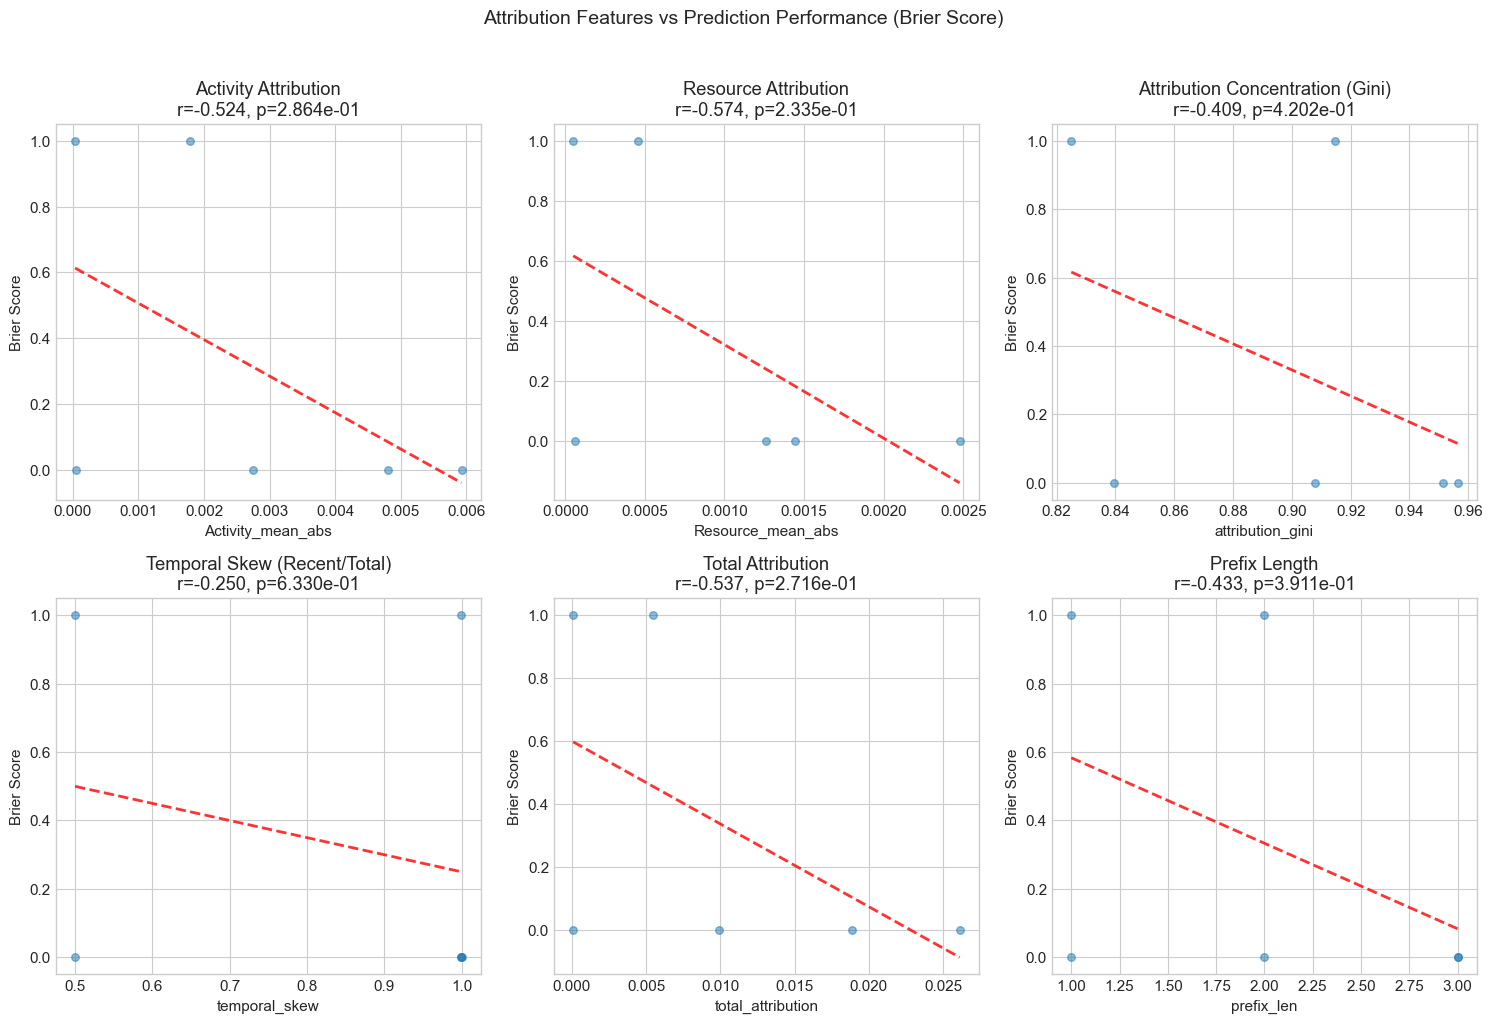

In [12]:
# Visualization: Scatter plots of key attribution features vs Brier score
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

plot_features = [
    ('Activity_mean_abs', 'Activity Attribution'),
    ('Resource_mean_abs', 'Resource Attribution'),
    ('attribution_gini', 'Attribution Concentration (Gini)'),
    ('temporal_skew', 'Temporal Skew (Recent/Total)'),
    ('total_attribution', 'Total Attribution'),
    ('prefix_len', 'Prefix Length')
]

for ax, (col, title) in zip(axes.flat, plot_features):
    if col in features_df.columns:
        valid = features_df[[col, 'brier_score']].dropna()
        ax.scatter(valid[col], valid['brier_score'], alpha=0.5, s=30)
        
        # Add trend line
        z = np.polyfit(valid[col], valid['brier_score'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', alpha=0.8, linewidth=2)
        
        # Correlation
        r, pval = stats.pearsonr(valid[col], valid['brier_score'])
        ax.set_title(f'{title}\nr={r:.3f}, p={pval:.3e}')
        ax.set_xlabel(col)
        ax.set_ylabel('Brier Score')

plt.suptitle('Attribution Features vs Prediction Performance (Brier Score)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

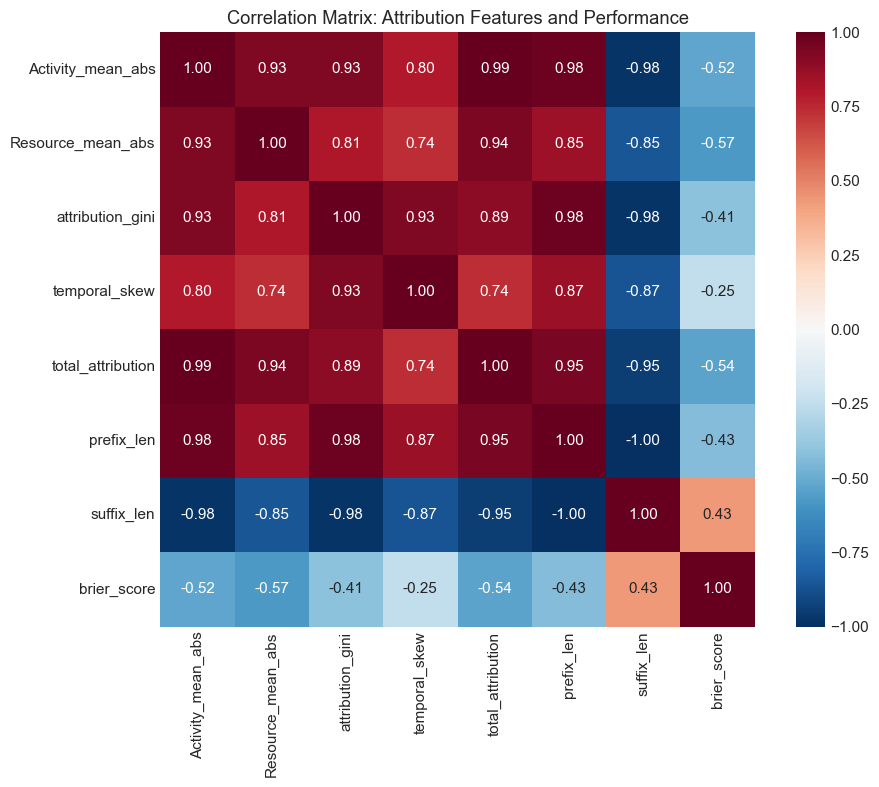

In [13]:
# Correlation heatmap
heatmap_cols = ['Activity_mean_abs', 'Resource_mean_abs', 'attribution_gini', 
                'temporal_skew', 'total_attribution', 'prefix_len', 'suffix_len', 'brier_score']
heatmap_cols = [c for c in heatmap_cols if c in features_df.columns]

corr_matrix = features_df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, 
            fmt='.2f', ax=ax, square=True)
ax.set_title('Correlation Matrix: Attribution Features and Performance')
plt.tight_layout()
plt.show()

---
## Section 2b: Attribution Impact on Certainty

We analyze whether attribution patterns predict model certainty (Shannon entropy).

In [14]:
# Correlation analysis: Attribution features vs Shannon entropy
correlations_entropy = {}
for col in attribution_cols:
    valid_mask = ~(features_df[col].isna() | features_df['shannon_entropy'].isna())
    if valid_mask.sum() >= MIN_SAMPLES_FOR_CORRELATION:
        try:
            r, p = stats.pearsonr(
                features_df.loc[valid_mask, col],
                features_df.loc[valid_mask, 'shannon_entropy']
            )
            if not np.isnan(r):
                correlations_entropy[col] = {'r': r, 'p': p}
        except Exception as e:
            pass  # Skip columns that fail correlation

# Display sorted by absolute correlation
if correlations_entropy:
    corr_df_entropy = pd.DataFrame(correlations_entropy).T
    corr_df_entropy['abs_r'] = corr_df_entropy['r'].abs()
    corr_df_entropy = corr_df_entropy.sort_values('abs_r', ascending=False)

    print("Correlation with Shannon Entropy (Uncertainty):")
    print("="*60)
    for idx, row in corr_df_entropy.head(15).iterrows():
        sig = "***" if row['p'] < 0.001 else "**" if row['p'] < 0.01 else "*" if row['p'] < 0.05 else ""
        print(f"{idx:30s}: r={row['r']:+.4f}, p={row['p']:.4e} {sig}")
else:
    print("Insufficient data for correlation analysis with Shannon Entropy.")
    print(f"Only {len(features_df)} samples available. Need more data for meaningful correlations.")
    corr_df_entropy = pd.DataFrame()

Insufficient data for correlation analysis with Shannon Entropy.
Only 6 samples available. Need more data for meaningful correlations.


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_37851/2520614550.py:7: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(


In [15]:
# Multiple regression: Entropy ~ Attribution features + controls
# Note: Control for prefix_len is crucial as it strongly affects entropy

if len(reg_df) > 20:
    # Prepare data for entropy regression
    reg_df_entropy = features_df[available_cols + ['shannon_entropy']].dropna()
    
    X = reg_df_entropy[available_cols]
    X = sm.add_constant(X)
    y = reg_df_entropy['shannon_entropy']
    
    model_ols_entropy = sm.OLS(y, X).fit()
    
    print("\n" + "="*80)
    print("OLS Regression: Shannon Entropy ~ Attribution Features")
    print("="*80)
    print(model_ols_entropy.summary())
else:
    print("Insufficient data for regression analysis")

Insufficient data for regression analysis


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_37851/1371003747.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, pval = stats.pearsonr(valid[col], valid['shannon_entropy'])
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_37851/1371003747.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, pval = stats.pearsonr(valid[col], valid['shannon_entropy'])
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_37851/1371003747.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, pval = stats.pearsonr(valid[col], valid['shannon_entropy'])
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_37851/1371003747.py:16: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, pval = stats.pearsonr(valid[col], valid['shannon_entropy'])
/var/folders/fh/1zxjz34s399g78gx

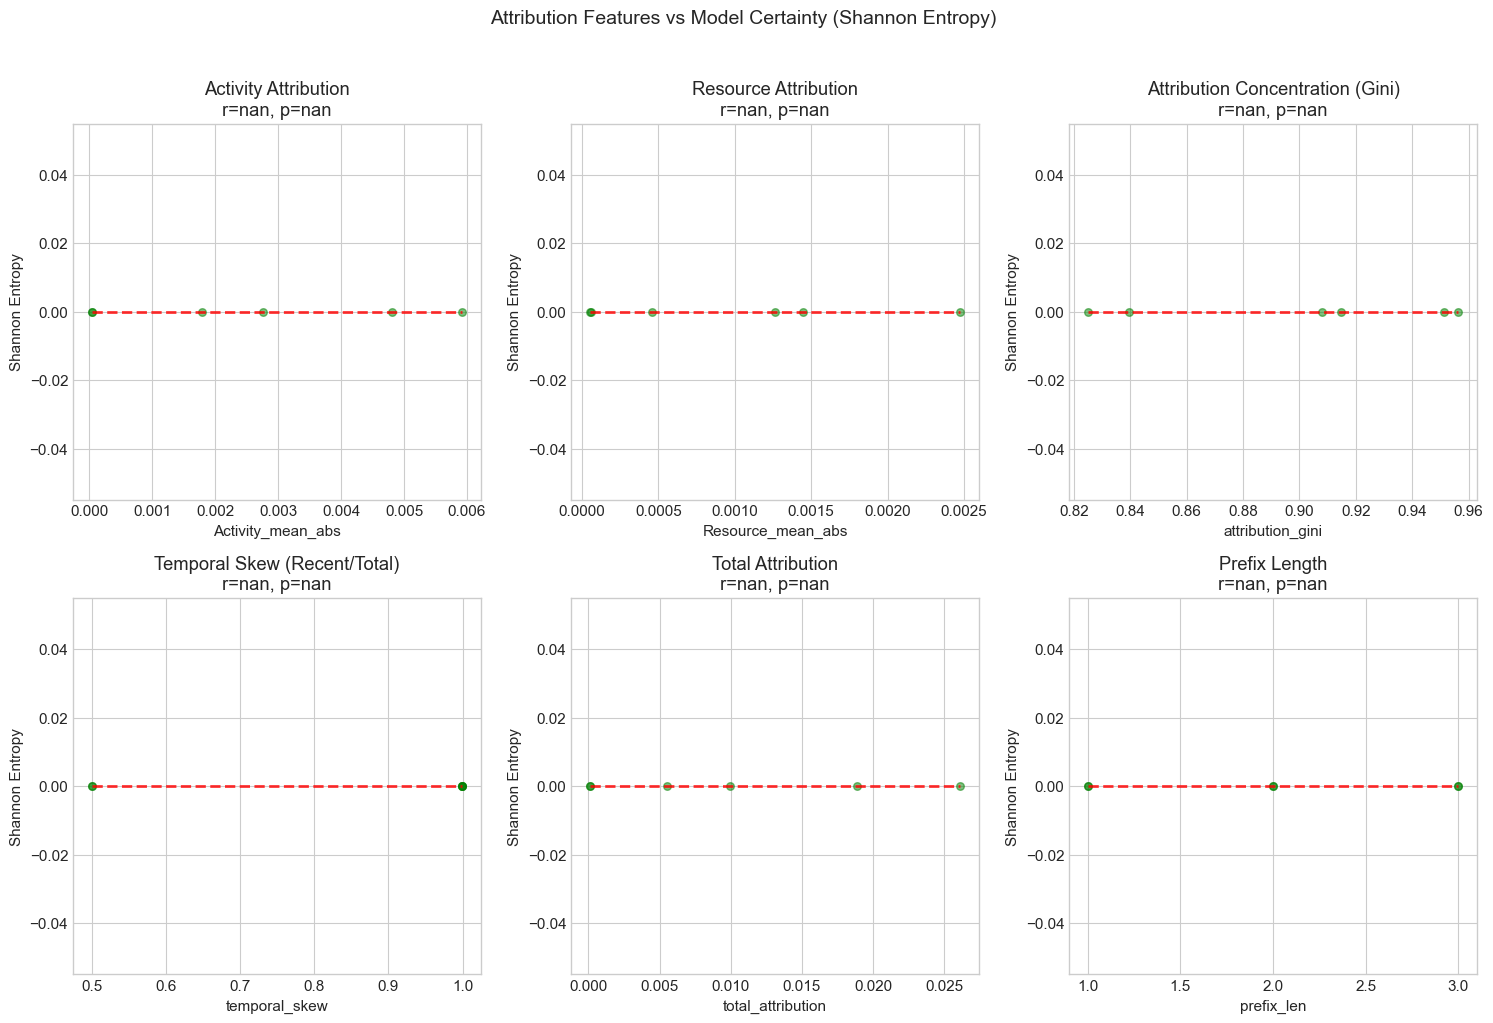

In [16]:
# Visualization: Scatter plots of key attribution features vs Shannon entropy
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for ax, (col, title) in zip(axes.flat, plot_features):
    if col in features_df.columns:
        valid = features_df[[col, 'shannon_entropy']].dropna()
        ax.scatter(valid[col], valid['shannon_entropy'], alpha=0.5, s=30, color='green')
        
        # Add trend line
        z = np.polyfit(valid[col], valid['shannon_entropy'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(valid[col].min(), valid[col].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', alpha=0.8, linewidth=2)
        
        # Correlation
        r, pval = stats.pearsonr(valid[col], valid['shannon_entropy'])
        ax.set_title(f'{title}\nr={r:.3f}, p={pval:.3e}')
        ax.set_xlabel(col)
        ax.set_ylabel('Shannon Entropy')

plt.suptitle('Attribution Features vs Model Certainty (Shannon Entropy)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

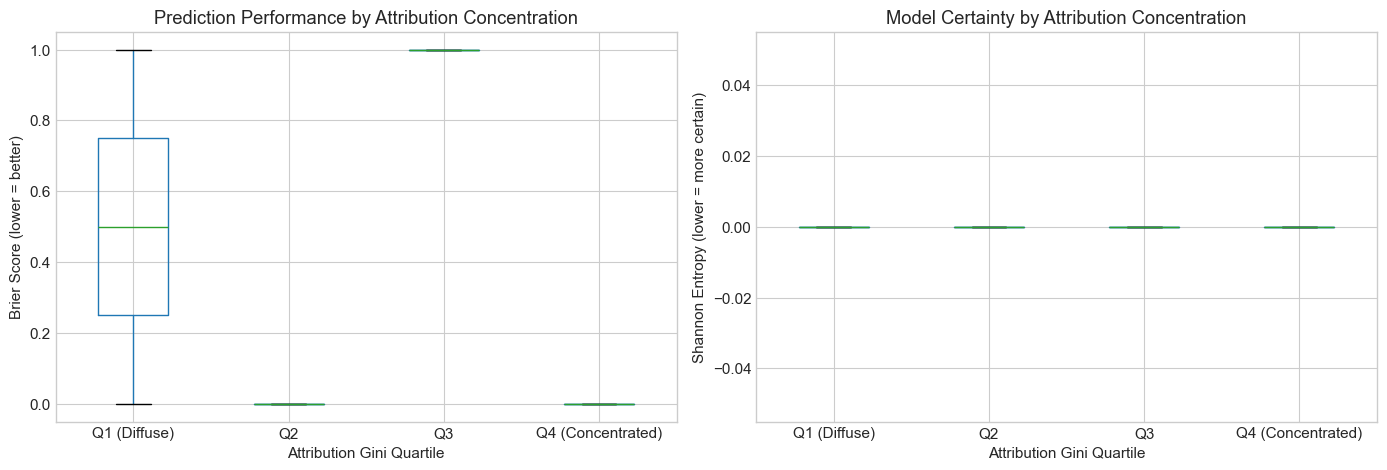


Mean Brier Score by Gini Quartile:
gini_quartile
Q1 (Diffuse)         0.5
Q2                   0.0
Q3                   1.0
Q4 (Concentrated)    0.0
Name: brier_score, dtype: float64

Mean Shannon Entropy by Gini Quartile:
gini_quartile
Q1 (Diffuse)         0.0
Q2                   0.0
Q3                   0.0
Q4 (Concentrated)    0.0
Name: shannon_entropy, dtype: float64


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_37851/1171267497.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(features_df.groupby('gini_quartile')['brier_score'].mean())
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_37851/1171267497.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(features_df.groupby('gini_quartile')['shannon_entropy'].mean())


In [17]:
# Deep dive: Attribution concentration (Gini) vs outcomes
# Hypothesis: Concentrated attribution → lower uncertainty

if 'attribution_gini' in features_df.columns:
    # Create Gini quartiles
    features_df['gini_quartile'] = pd.qcut(
        features_df['attribution_gini'].rank(method='first'),
        q=4,
        labels=['Q1 (Diffuse)', 'Q2', 'Q3', 'Q4 (Concentrated)']
    )
    
    # Box plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Brier score by Gini quartile
    features_df.boxplot(column='brier_score', by='gini_quartile', ax=axes[0])
    axes[0].set_title('Prediction Performance by Attribution Concentration')
    axes[0].set_xlabel('Attribution Gini Quartile')
    axes[0].set_ylabel('Brier Score (lower = better)')
    
    # Shannon entropy by Gini quartile
    features_df.boxplot(column='shannon_entropy', by='gini_quartile', ax=axes[1])
    axes[1].set_title('Model Certainty by Attribution Concentration')
    axes[1].set_xlabel('Attribution Gini Quartile')
    axes[1].set_ylabel('Shannon Entropy (lower = more certain)')
    
    plt.suptitle('')  # Remove automatic title
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print("\nMean Brier Score by Gini Quartile:")
    print(features_df.groupby('gini_quartile')['brier_score'].mean())
    
    print("\nMean Shannon Entropy by Gini Quartile:")
    print(features_df.groupby('gini_quartile')['shannon_entropy'].mean())

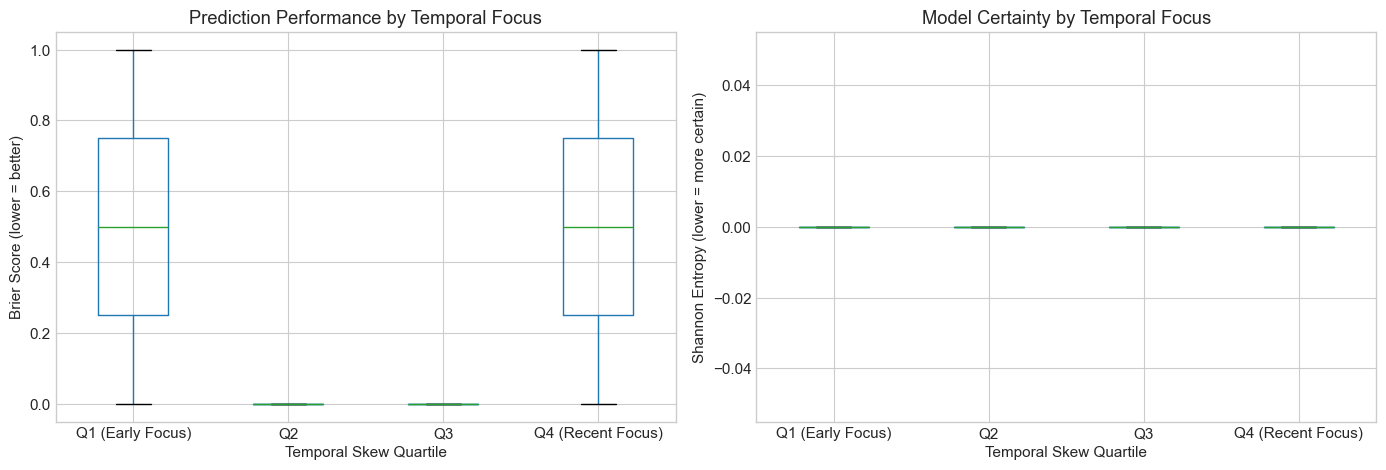


Mean Brier Score by Temporal Skew Quartile:
skew_quartile
Q1 (Early Focus)     0.5
Q2                   0.0
Q3                   0.0
Q4 (Recent Focus)    0.5
Name: brier_score, dtype: float64

Mean Shannon Entropy by Temporal Skew Quartile:
skew_quartile
Q1 (Early Focus)     0.0
Q2                   0.0
Q3                   0.0
Q4 (Recent Focus)    0.0
Name: shannon_entropy, dtype: float64


/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_37851/1984226262.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(features_df.groupby('skew_quartile')['brier_score'].mean())
/var/folders/fh/1zxjz34s399g78gxldrn5cth0000gn/T/ipykernel_37851/1984226262.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(features_df.groupby('skew_quartile')['shannon_entropy'].mean())


In [18]:
# Deep dive: Temporal skew (recent vs early attribution)
# Hypothesis: Higher recent attribution → better predictions

if 'temporal_skew' in features_df.columns:
    # Create temporal skew quartiles
    features_df['skew_quartile'] = pd.qcut(
        features_df['temporal_skew'].rank(method='first'),
        q=4,
        labels=['Q1 (Early Focus)', 'Q2', 'Q3', 'Q4 (Recent Focus)']
    )
    
    # Box plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    features_df.boxplot(column='brier_score', by='skew_quartile', ax=axes[0])
    axes[0].set_title('Prediction Performance by Temporal Focus')
    axes[0].set_xlabel('Temporal Skew Quartile')
    axes[0].set_ylabel('Brier Score (lower = better)')
    
    features_df.boxplot(column='shannon_entropy', by='skew_quartile', ax=axes[1])
    axes[1].set_title('Model Certainty by Temporal Focus')
    axes[1].set_xlabel('Temporal Skew Quartile')
    axes[1].set_ylabel('Shannon Entropy (lower = more certain)')
    
    plt.suptitle('')
    plt.tight_layout()
    plt.show()
    
    print("\nMean Brier Score by Temporal Skew Quartile:")
    print(features_df.groupby('skew_quartile')['brier_score'].mean())
    
    print("\nMean Shannon Entropy by Temporal Skew Quartile:")
    print(features_df.groupby('skew_quartile')['shannon_entropy'].mean())

---
## Summary and Key Findings

In [19]:
# Summary statistics
print("="*80)
print("SUMMARY: Attribution Analysis Results")
print("="*80)

print(f"\nTotal samples analyzed: {len(features_df)}")

if len(corr_df_brier) > 0:
    print("\n--- Top Correlates with Brier Score (Performance) ---")
    for idx, row in corr_df_brier.head(5).iterrows():
        direction = "higher" if row['r'] > 0 else "lower"
        outcome = "worse" if row['r'] > 0 else "better"
        print(f"  {idx}: {direction} value → {outcome} predictions (r={row['r']:.3f})")
else:
    print("\n--- Brier Score Correlations ---")
    print("  Insufficient samples for correlation analysis")

if len(corr_df_entropy) > 0:
    print("\n--- Top Correlates with Shannon Entropy (Uncertainty) ---")
    for idx, row in corr_df_entropy.head(5).iterrows():
        direction = "higher" if row['r'] > 0 else "lower"
        outcome = "more uncertain" if row['r'] > 0 else "more certain"
        print(f"  {idx}: {direction} value → {outcome} predictions (r={row['r']:.3f})")
else:
    print("\n--- Shannon Entropy Correlations ---")
    print("  Insufficient samples for correlation analysis")

SUMMARY: Attribution Analysis Results

Total samples analyzed: 6

--- Top Correlates with Brier Score (Performance) ---
  service_type_mean_abs: lower value → better predictions (r=-0.637)
  customer_first: lower value → better predictions (r=-0.619)
  service_type_sum_abs: lower value → better predictions (r=-0.602)
  Resource_mean_abs: lower value → better predictions (r=-0.574)
  customer_sum_abs: lower value → better predictions (r=-0.571)

--- Shannon Entropy Correlations ---
  Insufficient samples for correlation analysis


### Key Findings

Document your observations here after running the notebook:

**Section 2a: Attribution Impact on Performance**
1. Which attribution features most strongly predict Brier score?
2. Does higher total attribution lead to better or worse predictions?
3. Is concentrated attribution (high Gini) associated with better performance?

**Section 2b: Attribution Impact on Certainty**
1. Which attribution features most strongly predict Shannon entropy?
2. Does temporal skew (recent vs early focus) affect certainty?
3. After controlling for prefix length, do attribution patterns still predict uncertainty?

**Hypotheses Tested:**
- [ ] Concentrated attribution → lower uncertainty
- [ ] Recent attribution focus → better predictions
- [ ] Higher Activity attribution → more accurate activity predictions

In [20]:
# Save analysis results
# features_df.to_pickle('aggregated_attribution_analysis_results.pkl')
# print("Results saved to aggregated_attribution_analysis_results.pkl")